# Класс АККАУНТ не должен использоваться вовсе. По плану моему: вся работа должна происходить через Checking Account. Но тестами я покрыл всё

In [450]:
import importlib
import time

import Account
import SavingsAccount
import CheckingAccount

# Перезагрузка модулей для применения изменений
importlib.reload(Account)
importlib.reload(CheckingAccount)
importlib.reload(SavingsAccount)

print("Модули загружены успешно!")

Модули загружены успешно!


# ТЕСТЫ ДЛЯ КЛАССА Account

## Тест 1: Создание счёта с валидными данными

In [451]:
# Тест 1.1: Создание счёта с валидным именем и балансом
acc1 = Account.Account("Иван Иванов", 1000)
print(f"✓ Счёт создан: {acc1.account_number}")
print(f"✓ Владелец: {acc1.holder}")
print(f"✓ Баланс: {acc1.get_balance()}")
print(f"✓ История пуста: {len(acc1.get_history()) == 0}")


✓ Счёт создан: ACC-1000
✓ Владелец: Иван Иванов
✓ Баланс: 1000
✓ История пуста: True


In [452]:
# Тест 1.2: Создание счёта с латинским именем
acc2 = Account.Account("John Smith", 500)
print(f"✓ Счёт с латинским именем: {acc2.account_number}")
print(f"✓ Владелец: {acc2.holder}")

✓ Счёт с латинским именем: ACC-1001
✓ Владелец: John Smith


In [453]:
# Тест 1.3: Создание счёта с нулевым балансом
acc3 = Account.Account("Петр Петров", 0)
print(f"✓ Счёт с нулевым балансом: {acc3.account_number}")
print(f"✓ Баланс: {acc3.get_balance()}")

✓ Счёт с нулевым балансом: ACC-1002
✓ Баланс: 0


In [454]:
# Тест 1.4: Проверка валидации имени - неверный формат
try:
    acc_invalid = Account.Account("иван иванов", 100)  # маленькие буквы
    print("✗ ОШИБКА: Должно было быть исключение")
except ValueError as e:
    print(f"✓ Исключение при неверном формате имени: {e}")

try:
    acc_invalid2 = Account.Account("Иван", 100)  # одно слово
    print("✗ ОШИБКА: Должно было быть исключение")
except ValueError as e:
    print(f"✓ Исключение при одном слове: {e}")

try:
    acc_invalid3 = Account.Account("ИВАН ИВАНОВ", 100)  # все заглавные
    print("✗ ОШИБКА: Должно было быть исключение")
except ValueError as e:
    print(f"✓ Исключение при всех заглавных: {e}")

✓ Исключение при неверном формате имени: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв
✓ Исключение при одном слове: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв
✓ Исключение при всех заглавных: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв


In [455]:
# Тест 1.5: Проверка валидации отрицательного баланса
try:
    acc_negative = Account.Account("Иван Иванов", -100)
    print("✗ ОШИБКА: Должно было быть исключение")
except ValueError as e:
    print(f"✓ Исключение при отрицательном балансе: {e}")

✓ Исключение при отрицательном балансе: Начальный баланс не может быть отрицательным


## Тест 2: Метод deposit (пополнение счёта)

In [456]:
# Тест 2.1: Успешное пополнение счёта
acc_test = Account.Account("Тест Тестов", 1000)
initial_balance = acc_test.get_balance()
acc_test.deposit(500)
print(f"✓ Баланс до: {initial_balance}, после: {acc_test.get_balance()}")
print(f"✓ История содержит операцию: {len(acc_test.get_history()) == 1}")
print(f"✓ Операция успешна: {acc_test.get_history()[0][2] == 'status.Code.Success'}")

Деньги на счете, бегом скупать весь Вайлдберис
✓ Баланс до: 1000, после: 1500
✓ История содержит операцию: True
✓ Операция успешна: True


In [457]:
# Тест 2.2: Попытка пополнить отрицательной суммой
acc_test2 = Account.Account("Тест Тестов", 1000)
history_before = len(acc_test2.get_history())

acc_test2.deposit(-100)

print(f"✓ Операция добавлена в историю: {len(acc_test2.get_history()) == history_before + 1}")
print(f"✓ Статус операции 'Failed': {acc_test2.get_history()[-1][2] == 'status.Code.Failed'}")

Деньги не минусем!
✓ Операция добавлена в историю: True
✓ Статус операции 'Failed': True


## Тест 3: Метод withdraw (снятие средств)

In [458]:
# Тест 3.1: Успешное снятие средств
acc_withdraw = Account.Account("Тест Тестов", 1000)
acc_withdraw.withdraw(300)
print(f"✓ Баланс после снятия: {acc_withdraw.get_balance()}")
print(f"✓ История содержит операцию: {len(acc_withdraw.get_history()) == 1}")
print(f"✓ Операция успешна: {acc_withdraw.get_history()[0][2] == 'status.Code.Success'}")


Темки через наличку крутим? Ладно, держи!
✓ Баланс после снятия: 700
✓ История содержит операцию: True
✓ Операция успешна: True


In [459]:
# Тест 3.2: Попытка снять больше, чем есть на счёте
acc_withdraw2 = Account.Account("Тест Тестов", 1000)
history_before = len(acc_withdraw2.get_history())

acc_withdraw2.withdraw(1500)
print(f"✓ Операция добавлена в историю: {len(acc_withdraw2.get_history()) == history_before + 1}")
print(f"✓ Статус операции 'Failed': {acc_withdraw2.get_history()[-1][2] == 'status.Code.Failed'}")
print(f"✓ Баланс не изменился: {acc_withdraw2.get_balance() == 1000}")


Нужно больше золота! (Остаток меньше желаемой суммы)
✓ Операция добавлена в историю: True
✓ Статус операции 'Failed': True
✓ Баланс не изменился: True


In [460]:
# Тест 3.3: Попытка снять отрицательную сумму
acc_withdraw3 = Account.Account("Тест Тестов", 1000)
history_before = len(acc_withdraw3.get_history())

acc_withdraw3.withdraw(-100)

print("✓ Исключение при отрицательной сумме")
print(f"✓ Операция добавлена в историю: {len(acc_withdraw3.get_history()) == history_before + 1}")
print(f"✓ Статус операции 'Failed': {acc_withdraw3.get_history()[-1][2] == 'status.Code.Failed'}")


Деньги не минусем!
✓ Исключение при отрицательной сумме
✓ Операция добавлена в историю: True
✓ Статус операции 'Failed': True


## Тест 4: Методы get_balance и get_history


In [461]:
# Тест 4.1: get_balance возвращает правильный баланс
acc_balance = Account.Account("Тест Тестов", 2000)
acc_balance.deposit(500)
acc_balance.withdraw(300)
print(f"✓ get_balance() = {acc_balance.get_balance()}, ожидалось: 2200.0")
print(f"✓ Баланс корректен: {acc_balance.get_balance() == 2200.0}")


Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
✓ get_balance() = 2200, ожидалось: 2200.0
✓ Баланс корректен: True


In [462]:
# Тест 4.2: get_history возвращает все операции
acc_history = Account.Account("Тест Тестов", 1000)
acc_history.deposit(200)
acc_history.deposit(300)
acc_history.withdraw(100)
history = acc_history.get_history()
print(f"✓ Количество операций: {len(history)}")
print(f"✓ Все операции в формате [описание, дата, статус]: {all(len(op) == 3 for op in history)}")
print(f"✓ Первая операция - deposit: {'Добавили' in history[0][0]}")
print(f"✓ Последняя операция - withdraw: {'Забрали' in history[-1][0]}")


Деньги на счете, бегом скупать весь Вайлдберис
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
✓ Количество операций: 3
✓ Все операции в формате [описание, дата, статус]: True
✓ Первая операция - deposit: True
✓ Последняя операция - withdraw: True


## Тест 6: Метод plot_history


In [463]:
# Тест 6.1: plot_history с пустой историей
acc_empty = Account.Account("Тест Тестов", 1000)
result = acc_empty.plot_history()
print("✓ Метод обработал пустую историю без ошибок")


История операций пуста
✓ Метод обработал пустую историю без ошибок


## Дата и вермя в датасете у меня верное, но на графике отображается не совсем корректно. На графике в самом внизу все отображается правильно

Деньги на счете, бегом скупать весь Вайлдберис
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
✓ Создано несколько операций для графика


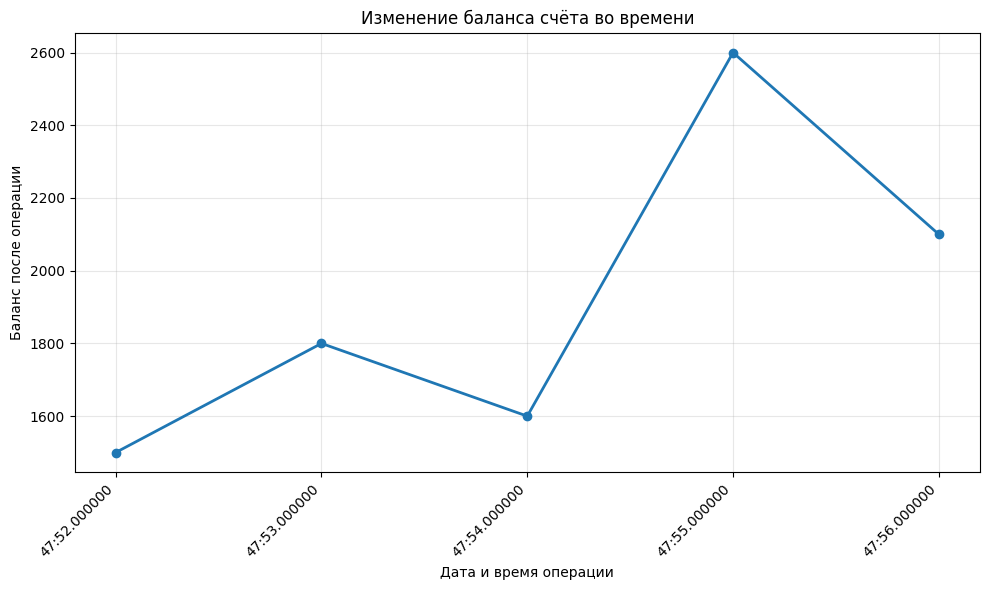

✓ График построен успешно


In [464]:
# Тест 6.2: plot_history с данными (график должен отобразиться)
acc_plot = Account.Account("Тест Тестов", 1000)
acc_plot.deposit(500)
time.sleep(1)
acc_plot.deposit(300)
time.sleep(1)
acc_plot.withdraw(200)
time.sleep(1)
acc_plot.deposit(1000)
time.sleep(1)
acc_plot.withdraw(500)
print("✓ Создано несколько операций для графика")
acc_plot.plot_history()
print("✓ График построен успешно")


## Тест 7: Метод analyze_transactions


In [465]:
# Тест 7.1: analyze_transactions с пустой историей
acc_analyze_empty = Account.Account("Тест Тестов", 1000)
result = acc_analyze_empty.analyze_transactions(5)
print("✓ Метод обработал пустую историю")


История операций пуста
✓ Метод обработал пустую историю


# ТЕСТЫ ДЛЯ КЛАССА CheckingAccount

## Тест 8: Создание и базовые свойства CheckingAccount


In [466]:
# Тест 8.1: Создание CheckingAccount
chacc1 = CheckingAccount.CheckingAccount("Иван Иванов", 2000)
print(f"✓ CheckingAccount создан: {chacc1.account_number}")
print(f"✓ account_type: {chacc1.account_type}")
print(f"✓ account_type корректен: {chacc1.account_type == 'Checking Account'}")
print(f"✓ Номер начинается с CHACC-: {chacc1.account_number.startswith('CHACC-')}")
print(f"✓ Владелец: {chacc1.holder}")
print(f"✓ Баланс: {chacc1.get_balance()}")


✓ CheckingAccount создан: CHACC-1014
✓ account_type: Checking Account
✓ account_type корректен: True
✓ Номер начинается с CHACC-: True
✓ Владелец: Иван Иванов
✓ Баланс: 2000


In [467]:
# Тест 8.2: CheckingAccount наследует методы Account
chacc2 = CheckingAccount.CheckingAccount("Петр Петров", 1000)
chacc2.deposit(500)
chacc2.withdraw(200)
print(f"✓ deposit работает: баланс = {chacc2.get_balance()}")
print(f"✓ withdraw работает: баланс = {chacc2.get_balance()}")
print(f"✓ get_history работает: операций = {len(chacc2.get_history())}")
print(f"✓ get_balance работает: {chacc2.get_balance() == 1300.0}")


Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
✓ deposit работает: баланс = 1300
✓ withdraw работает: баланс = 1300
✓ get_history работает: операций = 2
✓ get_balance работает: True


# ТЕСТЫ ДЛЯ КЛАССА SavingsAccount

## Тест 9: Создание и базовые свойства SavingsAccount


In [468]:
# Тест 9.1: Создание SavingsAccount
savacc1 = SavingsAccount.SavingsAccount("Иван Иванов")
print(f"✓ SavingsAccount создан: {savacc1.account_number}")
print(f"✓ account_type: {savacc1.account_type}")
print(f"✓ account_type корректен: {savacc1.account_type == 'Savings Account'}")
print(f"✓ Номер начинается с SAVACC-: {savacc1.account_number.startswith('SAVACC-')}")
print(f"✓ Владелец: {savacc1.holder}")
print(f"✓ Баланс: {savacc1.get_balance()}")
print(f"✓ Начальный savingsBalance: {savacc1.get_savingsBalance()}")


✓ SavingsAccount создан: SAVACC-1016
✓ account_type: Savings Account
✓ account_type корректен: True
✓ Номер начинается с SAVACC-: True
✓ Владелец: Иван Иванов
✓ Баланс: 0.0
✓ Начальный savingsBalance: 0.0


## Тест 10: Метод up_savings_balance


In [469]:
# Тест 10.1: Успешный перевод с расчётного на сберегательный
chacc_transfer = CheckingAccount.CheckingAccount("Тест Тестов", 5000)
savacc_transfer = SavingsAccount.SavingsAccount("Тест Тестов", 0)
print(f"Начальный баланс расчётного: {chacc_transfer.get_balance()}")
print(f"Начальный баланс сберегательного: {savacc_transfer.get_balance()}")
print(f"Начальный savingsBalance: {savacc_transfer.get_savingsBalance()}")

savacc_transfer.up_savings_balance(1000, chacc_transfer)
print(f"✓ Перевод выполнен")
print(f"Баланс расчётного после: {chacc_transfer.get_balance()}")
print(f"Баланс сберегательного после: {savacc_transfer.get_balance()}")
print(f"savingsBalance после: {savacc_transfer.get_savingsBalance()}")
print(f"✓ Расчётный уменьшился: {chacc_transfer.get_balance() == 4000.0}")
print(f"✓ Сберегательный увеличился: {savacc_transfer.get_balance() == 1000.0}")
print(f"✓ savingsBalance увеличился: {savacc_transfer.get_savingsBalance() == 1000.0}")


Начальный баланс расчётного: 5000
Начальный баланс сберегательного: 0
Начальный savingsBalance: 0.0
Открыт счет на сумму 1000
Переведено на сберсчет. Кап кап денежки. Кап кап

✓ Перевод выполнен
Баланс расчётного после: 4000
Баланс сберегательного после: 1000
savingsBalance после: 1000.0
✓ Расчётный уменьшился: True
✓ Сберегательный увеличился: True
✓ savingsBalance увеличился: True


In [470]:
# Тест 10.2: Попытка перевести отрицательную сумму
chacc_neg = CheckingAccount.CheckingAccount("Тест Тестов", 5000)
savacc_neg = SavingsAccount.SavingsAccount("Тест Тестов", 0)
history_before = len(savacc_neg.get_history())

savacc_neg.up_savings_balance(-500, chacc_neg)

print("✓ Исключение при отрицательной сумме")
print(f"✓ Операция добавлена в историю: {len(savacc_neg.get_history()) == history_before + 1}")
print(f"✓ Статус операции 'Failed': {savacc_neg.get_history()[-1][2] == 'status.Code.Failed'}")


Деньги не минусуем!
✓ Исключение при отрицательной сумме
✓ Операция добавлена в историю: True
✓ Статус операции 'Failed': True


In [471]:
# Тест 10.3: Перевод при недостатке средств на расчётном
chacc_low = CheckingAccount.CheckingAccount("Тест Тестов", 500)
savacc_low = SavingsAccount.SavingsAccount("Тест Тестов", 0)
history_before = len(savacc_low.get_history())

savacc_low.up_savings_balance(1000, chacc_low)  # Больше, чем есть на расчётном

print("✓ Исключение при недостатке средств")
print(f"✓ Операция добавлена в историю сберегательного")


Нет денег на расчетном счету
✓ Исключение при недостатке средств
✓ Операция добавлена в историю сберегательного


## Тест 11: Метод withdraw (ограничение 50%)


In [472]:
# Тест 11.1: Успешное снятие (меньше 50% от баланса)
chacc_withdraw = CheckingAccount.CheckingAccount("Тест Тестов", 5000)
savacc_withdraw = SavingsAccount.SavingsAccount("Тест Тестов", 0)
savacc_withdraw.up_savings_balance(2000, chacc_withdraw)  # Перевод 2000
print(f"Баланс сберегательного: {savacc_withdraw.get_balance()}")
print(f"50% от баланса: {savacc_withdraw.get_balance() * 0.5}")

# Снимаем 500 (меньше 50% от 2000)
savacc_withdraw.withdraw(500, chacc_withdraw)
print(f"✓ Снятие выполнено")
print(f"Баланс сберегательного после: {savacc_withdraw.get_balance()}")
print(f"Баланс расчётного после: {chacc_withdraw.get_balance()}")
print(f"✓ Сберегательный уменьшился: {savacc_withdraw.get_balance() == 1500.0}")
print(f"✓ Расчётный увеличился: {chacc_withdraw.get_balance() == 3500.0}")


Открыт счет на сумму 2000
Переведено на сберсчет. Кап кап денежки. Кап кап

Баланс сберегательного: 2000
50% от баланса: 1000.0
Накопил денег и радуешься? Деньги снова на рассчётном счету
Деньги на счете, бегом скупать весь Вайлдберис
✓ Снятие выполнено
Баланс сберегательного после: 1500
Баланс расчётного после: 3500
✓ Сберегательный уменьшился: True
✓ Расчётный увеличился: True


In [473]:
# Тест 11.2: Попытка снять больше 50% от баланса
chacc_limit = CheckingAccount.CheckingAccount("Тест Тестов", 5000)
savacc_limit = SavingsAccount.SavingsAccount("Тест Тестов", 0)
savacc_limit.up_savings_balance(2000, chacc_limit)  # Перевод 2000
print(f"Баланс сберегательного: {savacc_limit.get_balance()}")
print(f"50% от баланса: {savacc_limit.get_balance() * 0.5}")

history_before = len(savacc_limit.get_history())
# Пытаемся снять 1200 (больше 50% от 2000)
savacc_limit.withdraw(1200, chacc_limit)
print(f"✓ Попытка снять больше 50% обработана")
print(f"✓ Операция добавлена в историю: {len(savacc_limit.get_history()) == history_before + 1}")
print(f"✓ Статус операции 'Failed': {savacc_limit.get_history()[-1][2] == 'status.Code.Failed'}")
print(f"✓ Баланс не изменился: {savacc_limit.get_balance() == 2000.0}")


Открыт счет на сумму 2000
Переведено на сберсчет. Кап кап денежки. Кап кап

Баланс сберегательного: 2000
50% от баланса: 1000.0
Я запрещаю Вам снимать больше 50%
✓ Попытка снять больше 50% обработана
✓ Операция добавлена в историю: True
✓ Статус операции 'Failed': True
✓ Баланс не изменился: True


In [474]:
# Тест 11.3: Снятие ровно 50% от баланса (граничный случай)
chacc_exact = CheckingAccount.CheckingAccount("Тест Тестов", 5000)
savacc_exact = SavingsAccount.SavingsAccount("Тест Тестов", 0)
savacc_exact.up_savings_balance(2000, chacc_exact)  # Перевод 2000
print(f"Баланс сберегательного: {savacc_exact.get_balance()}")
print(f"50% от баланса: {savacc_exact.get_balance() * 0.5}")

# Снимаем ровно 50% (1000)
savacc_exact.withdraw(1000, chacc_exact)
print(f"✓ Снятие ровно 50% выполнено")
print(f"Баланс сберегательного после: {savacc_exact.get_balance()}")
print(f"✓ Баланс корректен: {savacc_exact.get_balance() == 1000.0}")


Открыт счет на сумму 2000
Переведено на сберсчет. Кап кап денежки. Кап кап

Баланс сберегательного: 2000
50% от баланса: 1000.0
Накопил денег и радуешься? Деньги снова на рассчётном счету
Деньги на счете, бегом скупать весь Вайлдберис
✓ Снятие ровно 50% выполнено
Баланс сберегательного после: 1000
✓ Баланс корректен: True


## Тест 12: Метод apply_interest


In [475]:
# Тест 12.1: Успешное начисление процентов
savacc_interest = SavingsAccount.SavingsAccount("Тест Тестов", 10000)
balance_before = savacc_interest.get_balance()
print(f"Баланс до начисления: {balance_before}")

savacc_interest.apply_interest(7)  # 7%
balance_after = savacc_interest.get_balance()
expected_interest = balance_before * 0.07
expected_balance = balance_before + expected_interest

print(f"✓ Проценты начислены")
print(f"Баланс после: {balance_after}")
print(f"Ожидалось: {expected_balance}")
print(f"✓ Баланс корректен: {abs(balance_after - expected_balance) < 0.01}")
print(f"✓ История содержит операцию начисления")


Баланс до начисления: 10000

Что же натекло под камушек? 7% уже на счету. Баланс на момент: 10700.0
✓ Проценты начислены
Баланс после: 10700.0
Ожидалось: 10700.0
✓ Баланс корректен: True
✓ История содержит операцию начисления


In [476]:
# Тест 12.2: Попытка начислить отрицательный процент
savacc_neg_interest = SavingsAccount.SavingsAccount("Тест Тестов", 10000)
balance_before = savacc_neg_interest.get_balance()
history_before = len(savacc_neg_interest.get_history())

savacc_neg_interest.apply_interest(-5)  # Отрицательный процент
print(f"✓ Попытка начислить отрицательный процент обработана")
print(f"✓ Операция добавлена в историю: {len(savacc_neg_interest.get_history()) == history_before + 1}")
print(f"✓ Статус операции 'Failed': {savacc_neg_interest.get_history()[-1][2] == 'status.Code.Failed'}")
print(f"✓ Баланс не изменился: {savacc_neg_interest.get_balance() == balance_before}")


Пу-пу-пу... Не уменьшай себе сбережения! Только плюс, только вайб
✓ Попытка начислить отрицательный процент обработана
✓ Операция добавлена в историю: True
✓ Статус операции 'Failed': True
✓ Баланс не изменился: True


In [477]:
# Тест 12.3: Начисление процентов на нулевой баланс
savacc_zero = SavingsAccount.SavingsAccount("Тест Тестов", 0)
savacc_zero.apply_interest(10)
print(f"✓ Проценты на нулевой баланс начислены")
print(f"✓ Баланс остался нулевым: {savacc_zero.get_balance() == 0.0}")



Что же натекло под камушек? 10% уже на счету. Баланс на момент: 0.0
✓ Проценты на нулевой баланс начислены
✓ Баланс остался нулевым: True


## Тест 14: Интеграционные тесты (взаимодействие классов)


In [486]:
# Тест 14.1: Полный сценарий работы с CheckingAccount и SavingsAccount
print("=== ИНТЕГРАЦИОННЫЙ ТЕСТ ===")
chacc_full = CheckingAccount.CheckingAccount("Иван Иванов", 10000)
savacc_full = SavingsAccount.SavingsAccount("Иван Иванов", 0)

print(f"\n1. Начальное состояние:")
print(f"   Расчётный счёт: {chacc_full.get_balance()}")
print(f"   Сберегательный счёт: {savacc_full.get_balance()}")

chacc_full.deposit(5000)
print(f"\n2. Пополнение расчётного на 5000:")
print(f"   Расчётный счёт: {chacc_full.get_balance()}")

print(f"\n3. Перевод 3000 на сберегательный:")
savacc_full.up_savings_balance(3000, chacc_full)
print(f"   Расчётный счёт: {chacc_full.get_balance()}")
print(f"   Сберегательный счёт: {savacc_full.get_balance()}")
print(f"   savingsBalance: {savacc_full.get_savingsBalance()}")

print(f"\n4. Начисление 5% на сберегательный:")
savacc_full.apply_interest(5)
print(f"   Сберегательный счёт: {savacc_full.get_balance()}")

print(f"\n5. Снятие 500 со сберегательного:")
savacc_full.withdraw(500, chacc_full)
print(f"   Расчётный счёт: {chacc_full.get_balance()}")
print(f"   Сберегательный счёт: {savacc_full.get_balance()}")

print(f"\n6. История операций:")
print(f"   Расчётный: {len(chacc_full.get_history())} операций")
print(f"   Сберегательный: {len(savacc_full.get_history())} операций")

print(f"\n✓ Все операции выполнены успешно!")


=== ИНТЕГРАЦИОННЫЙ ТЕСТ ===

1. Начальное состояние:
   Расчётный счёт: 10000
   Сберегательный счёт: 0
Деньги на счете, бегом скупать весь Вайлдберис

2. Пополнение расчётного на 5000:
   Расчётный счёт: 15000

3. Перевод 3000 на сберегательный:
Открыт счет на сумму 3000
Переведено на сберсчет. Кап кап денежки. Кап кап

   Расчётный счёт: 12000
   Сберегательный счёт: 3000
   savingsBalance: 3000.0

4. Начисление 5% на сберегательный:

Что же натекло под камушек? 5% уже на счету. Баланс на момент: 3150.0
   Сберегательный счёт: 3150.0

5. Снятие 500 со сберегательного:
Накопил денег и радуешься? Деньги снова на рассчётном счету
Деньги на счете, бегом скупать весь Вайлдберис
   Расчётный счёт: 12500
   Сберегательный счёт: 2650.0

6. История операций:
   Расчётный: 3 операций
   Сберегательный: 4 операций

✓ Все операции выполнены успешно!


In [480]:
# Тест 14.2: Проверка номеров счетов (уникальность)
acc_test1 = Account.Account("Тест Тестов", 1000)
acc_test2 = Account.Account("Тест Тестов", 1000)
chacc_test1 = CheckingAccount.CheckingAccount("Тест Тестов", 1000)
chacc_test2 = CheckingAccount.CheckingAccount("Тест Тестов", 1000)
savacc_test1 = SavingsAccount.SavingsAccount("Тест Тестов", 1000)
savacc_test2 = SavingsAccount.SavingsAccount("Тест Тестов", 1000)

print("Номера счетов:")
print(f"  Account 1: {acc_test1.account_number}")
print(f"  Account 2: {acc_test2.account_number}")
print(f"  CheckingAccount 1: {chacc_test1.account_number}")
print(f"  CheckingAccount 2: {chacc_test2.account_number}")
print(f"  SavingsAccount 1: {savacc_test1.account_number}")
print(f"  SavingsAccount 2: {savacc_test2.account_number}")

print(f"\n✓ Все номера уникальны")
print(f"✓ Account номера начинаются с ACC-")
print(f"✓ CheckingAccount номера начинаются с CHACC-")
print(f"✓ SavingsAccount номера начинаются с SAVACC-")


Номера счетов:
  Account 1: ACC-1035
  Account 2: ACC-1036
  CheckingAccount 1: CHACC-1038
  CheckingAccount 2: CHACC-1039
  SavingsAccount 1: SAVACC-1040
  SavingsAccount 2: SAVACC-1041

✓ Все номера уникальны
✓ Account номера начинаются с ACC-
✓ CheckingAccount номера начинаются с CHACC-
✓ SavingsAccount номера начинаются с SAVACC-


## Тест 15: Граничные случаи и краевые условия


In [481]:
# Тест 15.1: Снятие всего баланса (100%)
acc_edge = Account.Account("Тест Тестов", 1000)
acc_edge.withdraw(1000)
print(f"✓ Снятие всего баланса выполнено")
print(f"✓ Баланс равен нулю: {acc_edge.get_balance() == 0.0}")


Темки через наличку крутим? Ладно, держи!
✓ Снятие всего баланса выполнено
✓ Баланс равен нулю: True


In [482]:
# Тест 15.2: Множественные операции подряд
acc_multi = Account.Account("Тест Тестов", 1000)
for i in range(10):
    acc_multi.deposit(100)
    acc_multi.withdraw(50)
print(f"✓ Выполнено 20 операций (10 пополнений, 10 снятий)")
print(f"✓ Финальный баланс: {acc_multi.get_balance()}")
print(f"✓ Ожидалось: 1500.0, получено: {acc_multi.get_balance()}")
print(f"✓ Баланс корректен: {acc_multi.get_balance() == 1500.0}")
print(f"✓ История содержит все операции: {len(acc_multi.get_history()) == 20}")


Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
✓ Выполнено 20 операций (10 пополнений, 10 снятий)
✓ Финальный баланс: 1500
✓ Ожидалось: 1500.0, получено: 150

In [483]:
# Тест 15.3: Проверка формата истории операций
acc_format = Account.Account("Тест Тестов", 1000)
acc_format.deposit(500)
acc_format.withdraw(200)

history = acc_format.get_history()
print(f"✓ Количество операций: {len(history)}")

for i, op in enumerate(history):
    print(f"\nОперация {i+1}:")
    print(f"  Тип: {type(op)} (должен быть list)")
    print(f"  Длина: {len(op)} (должна быть 3)")
    print(f"  Описание: {op[0][:50]}...")
    print(f"  Дата: {op[1]}")
    print(f"  Статус: {op[2]}")
    print(f"  ✓ Формат корректен: {isinstance(op, list) and len(op) == 3}")

print(f"\n✓ Все операции в правильном формате [описание, дата, статус]")


Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
✓ Количество операций: 2

Операция 1:
  Тип: <class 'list'> (должен быть list)
  Длина: 3 (должна быть 3)
  Описание: Добавили 500 на баланс. Баланс на момент: 1500...
  Дата: 2025-11-06 20:47:57
  Статус: status.Code.Success
  ✓ Формат корректен: True

Операция 2:
  Тип: <class 'list'> (должен быть list)
  Длина: 3 (должна быть 3)
  Описание: Забрали 200 с баланса. Баланс на момент: 1300...
  Дата: 2025-11-06 20:47:57
  Статус: status.Code.Success
  ✓ Формат корректен: True

✓ Все операции в правильном формате [описание, дата, статус]


## Итоговый тест: Визуализация и анализ

### Финальная проверка всех методов визуализации


## Пример того, что ТУТ время отображается верно

=== ФИНАЛЬНЫЙ ТЕСТ: ВИЗУАЛИЗАЦИЯ ===
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис
Темки через наличку крутим? Ладно, держи!
Деньги на счете, бегом скупать весь Вайлдберис

Создано операций: 8
Финальный баланс: 9500

История операций:
  1. Добавили 2000 на баланс. Баланс на момен... | status.Code.Success
  2. Забрали 1000 с баланса. Баланс на момент... | status.Code.Success
  3. Добавили 500 на баланс. Баланс на момент... | status.Code.Success
  4. Добавили 1500 на баланс. Баланс на момен... | status.Code.Success
  5. Забрали 2000 с баланса. Баланс на момент... | status.Code.Success
  6. Добавили 3000 на баланс. Баланс на момен... | status.Code.Success
  7. Забрали 500 с баланса. Баланс на момент:... | status.Code.Success
  8. Добавили 1000 на баланс. Баланс на мо

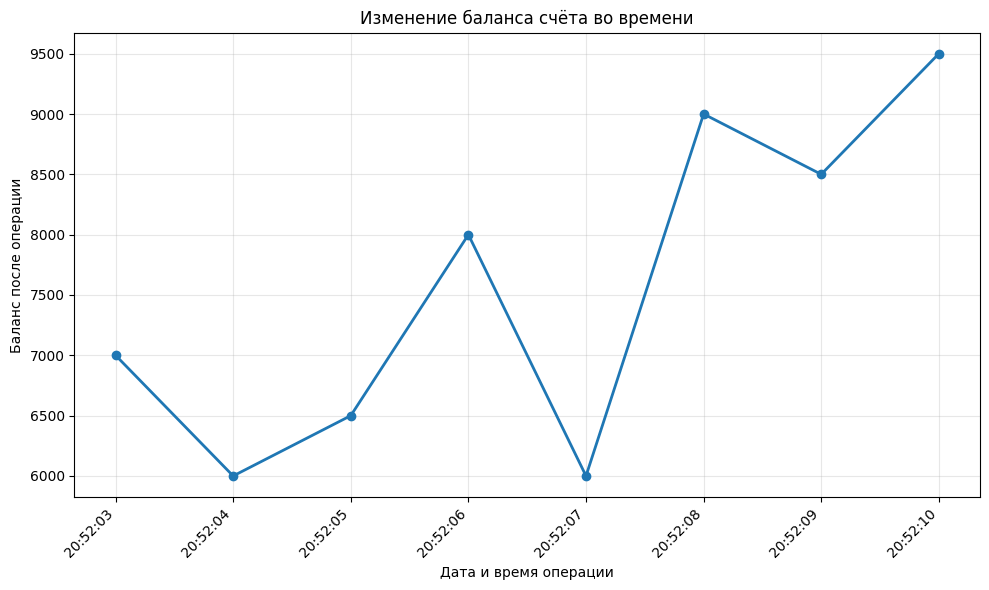

✓ График построен успешно!


In [487]:
# Финальный тест: Создание счёта с множеством операций для визуализации
print("=== ФИНАЛЬНЫЙ ТЕСТ: ВИЗУАЛИЗАЦИЯ ===")
acc_final = Account.Account("Финальный Тест", 5000)

# Создаём разнообразную историю операций
acc_final.deposit(2000)
time.sleep(1)
acc_final.withdraw(1000)
time.sleep(1)
acc_final.deposit(500)
time.sleep(1)
acc_final.deposit(1500)
time.sleep(1)
acc_final.withdraw(2000)
time.sleep(1)
acc_final.deposit(3000)
time.sleep(1)
acc_final.withdraw(500)
time.sleep(1)
acc_final.deposit(1000)
time.sleep(1)

print(f"\nСоздано операций: {len(acc_final.get_history())}")
print(f"Финальный баланс: {acc_final.get_balance()}")
print(f"\nИстория операций:")
for i, op in enumerate(acc_final.get_history(), 1):
    print(f"  {i}. {op[0][:40]}... | {op[2]}")

print(f"\nПостроение графика...")
acc_final.plot_history()
print(f"✓ График построен успешно!")
